Lets gather our tools:

- **TensorFlow** to build and train our models (our machine's brain),
- **Matplotlib** to visualize what the machine is seeing,
- **NumPy** for fast mathematical operations.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
from matplotlib import pyplot as plt

2025-04-07 15:46:59.215305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744030019.498628   14269 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744030019.579063   14269 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744030020.164580   14269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744030020.164641   14269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744030020.164651   14269 computation_placer.cc:177] computation placer alr

## **Load the dataset**

**CIFAR-10** — a dataset of tiny (32x32) colored pictures from 10 different categories.

👀 "Each picture is like a puzzle piece of our world: dogs, cats, ships, airplanes... Can our machine learn to tell them apart?"

We discover that there are:

- 50,000 training images,
- 10,000 test images

All neatly packed and labeled

In [2]:
(X_train, y_train),(X_test, y_test) = datasets.cifar10.load_data()

In [3]:
X_train.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
y_train.shape

(50000, 1)

## **Data Manipulation**

Every picture has a label, like a name tag.
We tidy these labels so our model can understand them better.
Now it’s ready to match pictures with names.

In [6]:
y_train = y_train.reshape(-1, )
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [7]:
y_test = y_test.reshape(-1, )
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

**Data Visualization**

Before we teach the machine, let’s look with our own eyes.

"Look! A frog 🐸, and next — a car 🚗!"

These images are small but mighty — each packed with visual cues.

In [8]:
# name our classses
classes = ["airplane","automobile","bird","cat",
           "deer","dog","frog","horse","ship","truck"]

def plot_sample(X, y, index):
    """
    This function plots an image from a specified index
    """
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

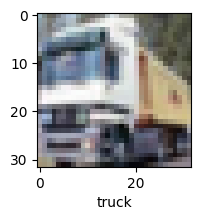

In [9]:
plot_sample(X_train, y_train, 1)

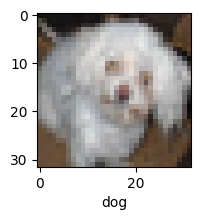

In [10]:
plot_sample(X_test, y_test, 1000)

### Modelling 

The machine sees colors from 0 to 255 — but that's a lot to process. Let’s normalize the vision!
By scaling pixel values to 0–1, we make learning easier, clearer, and faster.

In [11]:
# Normalization
X_train = X_train/255.0
X_test = X_test/255.0

Now we build a brain that can see like humans do!”

 - Convolutional layers look at small patches to detect edges, patterns, and features.

 - Pooling shrinks the image but keeps important parts.

Finally, we flatten and pass through dense layers for classification.

This is our CNN – the true eye of the machine.

In [12]:
# Create a basic CNN model 
from tensorflow.keras import models, layers

cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), 
                  input_shape=(32, 32, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), 
                  activation="relu"), 
    layers.MaxPooling2D((2, 2)), 

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

/home/the-ape/CurrentProjects/whatsapp-business/DSAI-course/DSAI_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-07 15:47:21.713263: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


We give our new brain a powerful optimizer: Adam — faster, smarter, better.

In [13]:
cnn.compile(optimizer='adam',
           loss='sparse_categorical_crossentropy',
           metrics=['accuracy'])

With every pass, the CNN sees more patterns, understands better, and becomes a reliable classifier.

In [14]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10


2025-04-07 15:47:23.813073: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 39ms/step - accuracy: 0.3698 - loss: 1.7142 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.5781 - loss: 1.1951
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.6338 - loss: 1.0435
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.6658 - loss: 0.9644
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.6959 - loss: 0.8842 
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.7107 - loss: 0.8343
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7294 - loss: 0.7828
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.7408 - loss: 0.7509
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7547 - loss: 0.7058
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7689 - loss: 0.6651


In [15]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6996 - loss: 0.9230


[0.9319297671318054, 0.6917999982833862]

**Preditions**

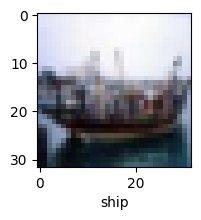

In [16]:
plot_sample(X_test, y_test, 18)

Now our CNN is trained — we build a small function.
Give it any test image and it will guess the object.

In [17]:
def make_prediction(X_value):
    image_sample = cnn.predict(np.array([X_value]))
    return classes[np.argmax([image_sample])]

In [18]:
make_prediction(X_test[18])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


'ship'

Try different test images and see if your model gets it right.
You’re now guiding a machine to see the world — just like a human child learning their ABCs of vision.

**Assignment**: Repeat the same using the MNISt digits dataset

In [19]:
(X_train, y_train),(X_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 
